In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("EDA environment is ready.")

Matplotlib is building the font cache; this may take a moment.


EDA environment is ready.


In [5]:
# Load the cleaned e-commerce dataset

file_path = "../data/cleaned/ecommerce_cleaned_mysql.csv"

df = pd.read_csv(file_path)

# Convert date columns
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed"
)

# Convert currency columns
df["Sales"] = (
    df["Sales"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["Profit"] = (
    df["Profit"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Convert quantity
df["Quantity"] = pd.to_numeric(df["Quantity"])

# Convert discount percentage to decimal
df["Discount"] = (
    df["Discount"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float) / 100
)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 9994
Columns: 21


In [6]:
# Basic dataset overview

print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (9994, 21)

Data Types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

Missing Values:
11

Duplicate Rows:
0


In [7]:
# Summary statistics for key business metrics

numeric_summary = df[["Sales", "Quantity", "Discount", "Profit"]].describe()

numeric_summary

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858022,3.789574,0.156203,28.656973
std,623.245131,2.225110,0.206452,234.260203
min,0.440000,1.000000,0.000000,-6599.980000
25%,17.280000,2.000000,0.000000,1.730000
50%,54.490000,3.000000,0.200000,8.665000
75%,209.940000,5.000000,0.200000,29.360000
max,22638.480000,14.000000,0.800000,8399.980000


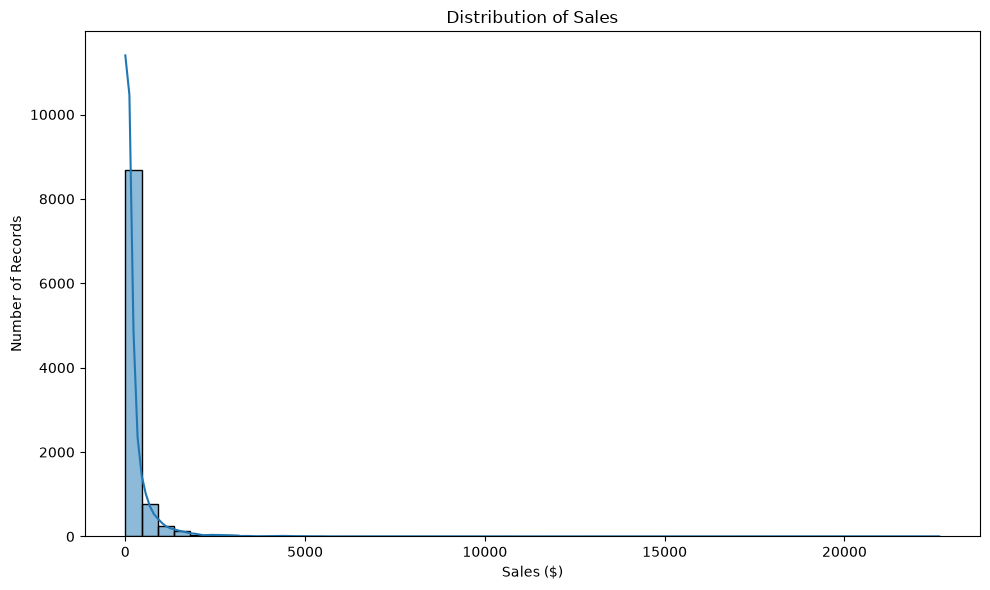

In [8]:
# Distribution of Sales

plt.figure(figsize=(10, 6))

sns.histplot(df["Sales"], bins=50, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

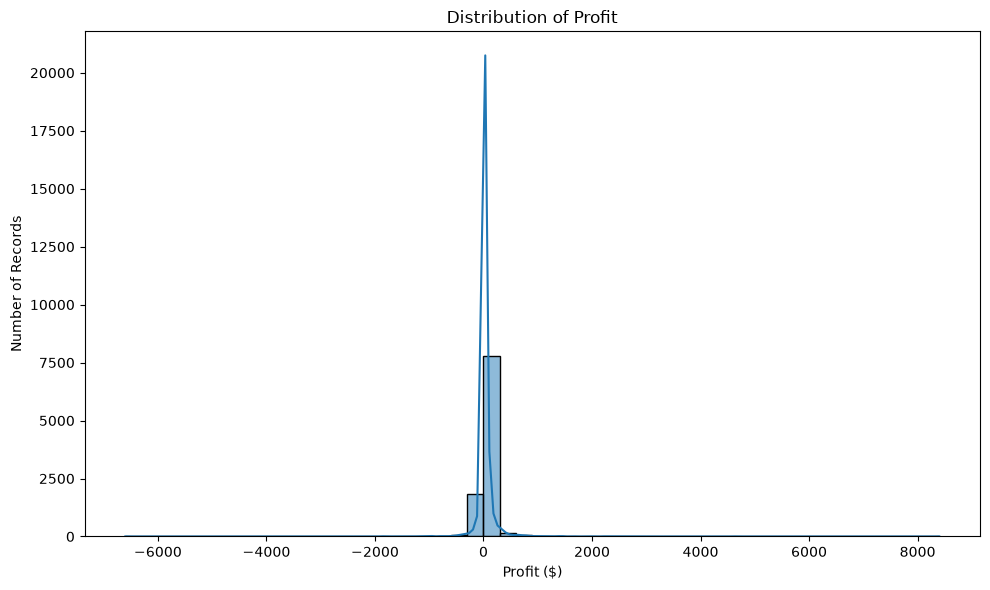

In [9]:
# Distribution of Profit

plt.figure(figsize=(10, 6))

sns.histplot(df["Profit"], bins=50, kde=True)

plt.title("Distribution of Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

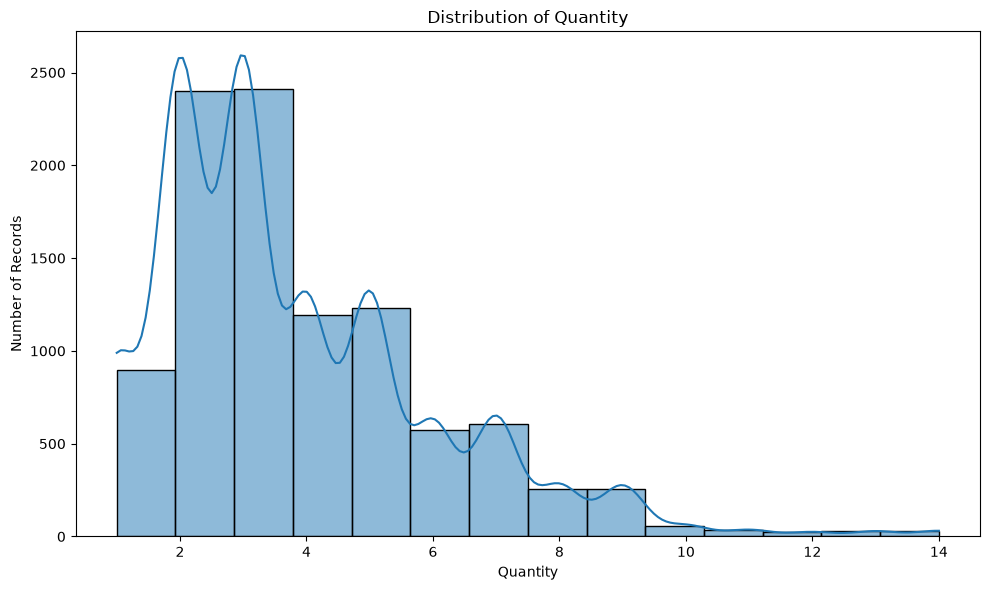

In [10]:
# Distribution of Quantity

plt.figure(figsize=(10, 6))

sns.histplot(df["Quantity"], bins=14, kde=True)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

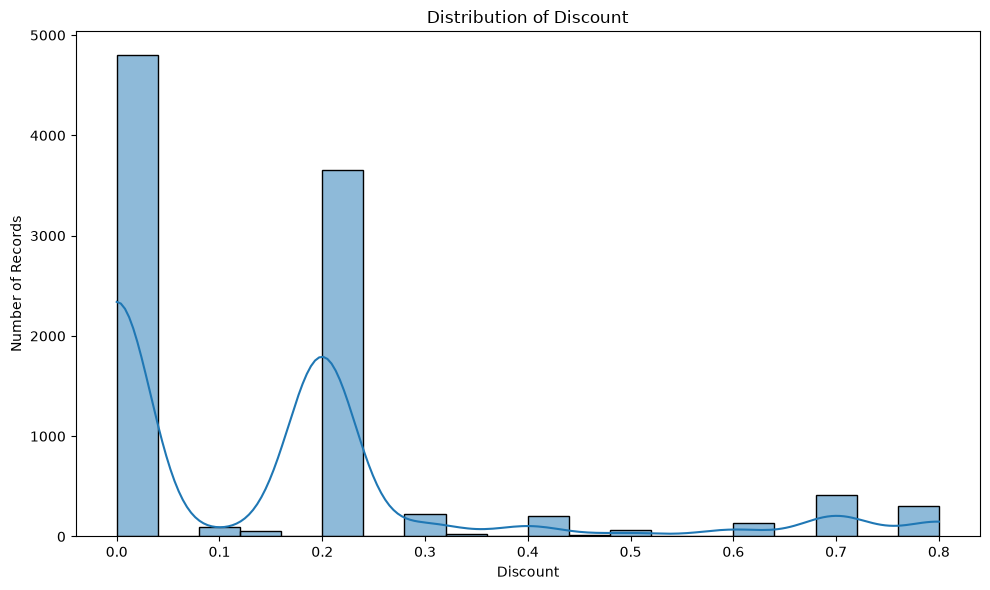

In [11]:
# Distribution of Discount

plt.figure(figsize=(10, 6))

sns.histplot(df["Discount"], bins=20, kde=True)

plt.title("Distribution of Discount")
plt.xlabel("Discount")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

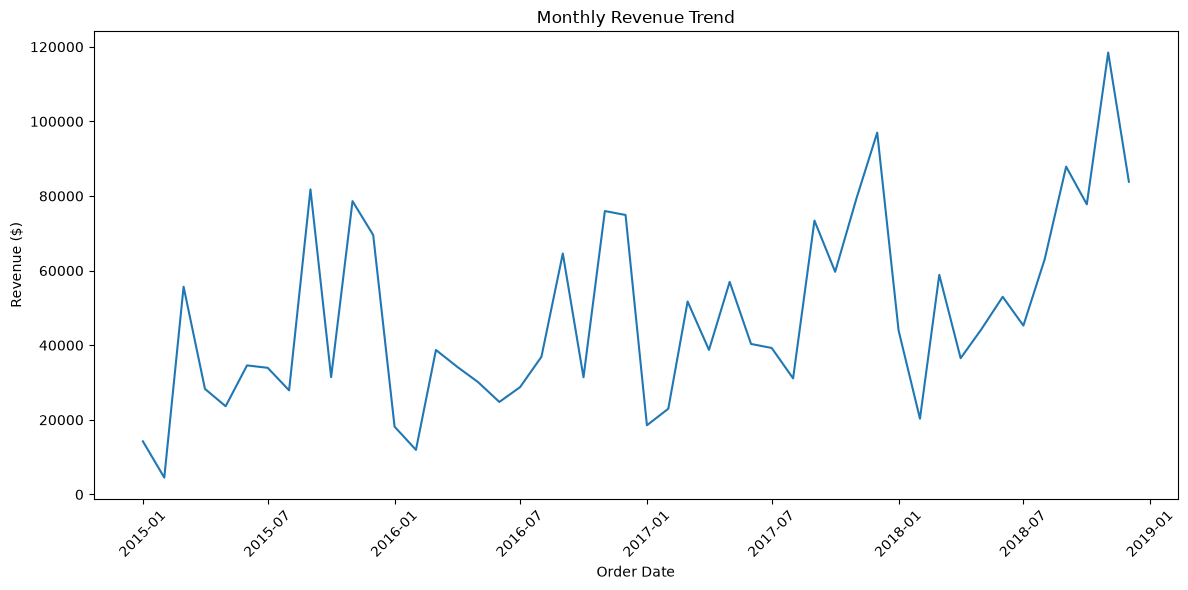

In [12]:
# Monthly Revenue Trend

monthly_revenue = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_revenue["Order Date"] = monthly_revenue["Order Date"].dt.to_timestamp()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_revenue,
    x="Order Date",
    y="Sales"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Order Date")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

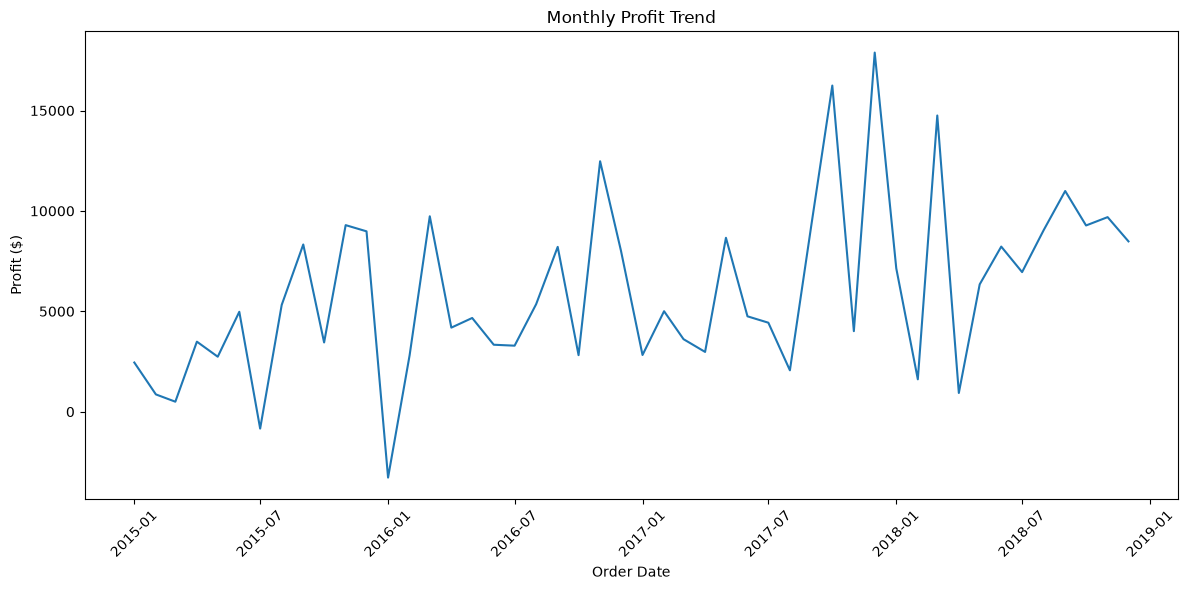

In [13]:
# Monthly Profit Trend

monthly_profit = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Profit"]
    .sum()
    .reset_index()
)

monthly_profit["Order Date"] = monthly_profit["Order Date"].dt.to_timestamp()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_profit,
    x="Order Date",
    y="Profit"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Order Date")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

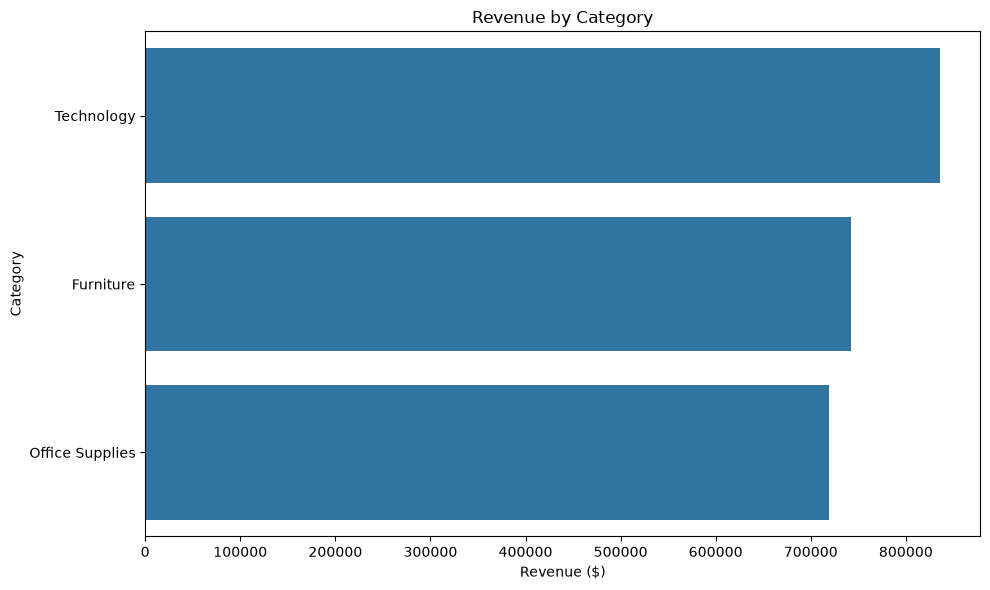

In [14]:
# Revenue by Category

category_revenue = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title("Revenue by Category")
plt.xlabel("Revenue ($)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

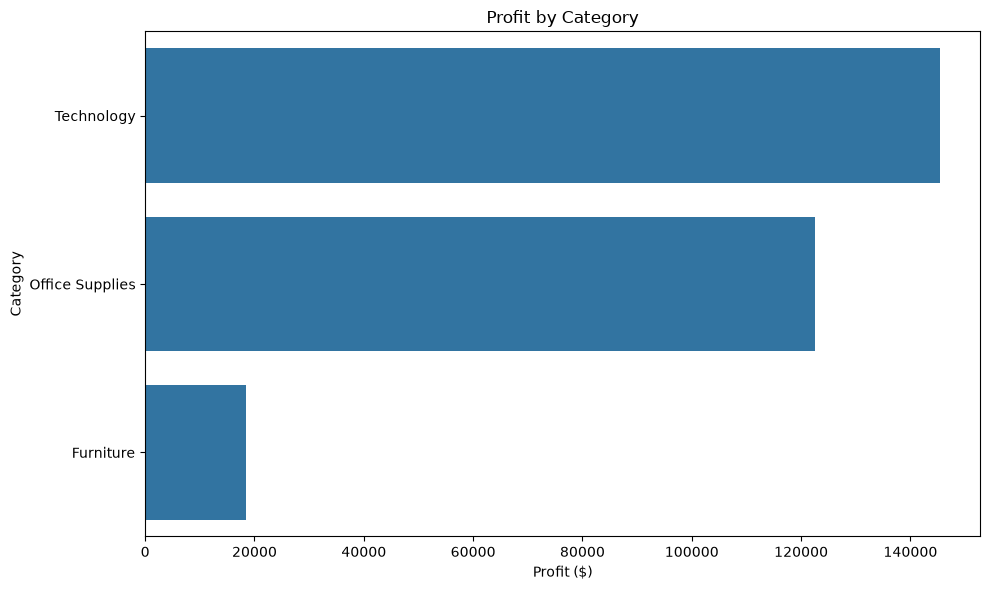

In [15]:
# Profit by Category

category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_profit.values,
    y=category_profit.index
)

plt.title("Profit by Category")
plt.xlabel("Profit ($)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

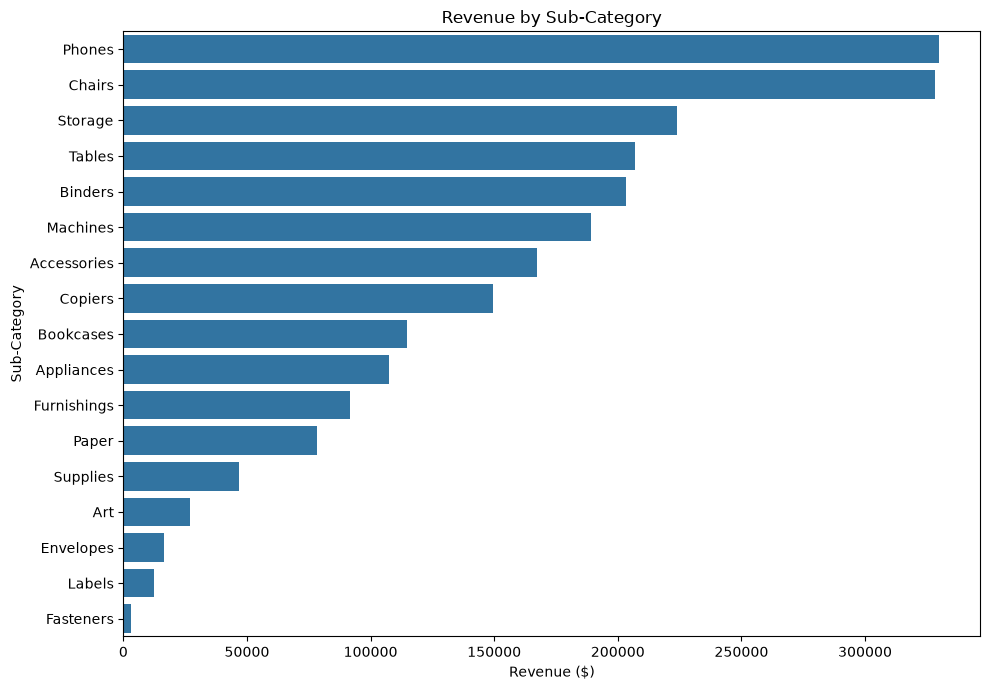

In [16]:
# Revenue by Sub-Category

subcategory_revenue = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=subcategory_revenue.values,
    y=subcategory_revenue.index
)

plt.title("Revenue by Sub-Category")
plt.xlabel("Revenue ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

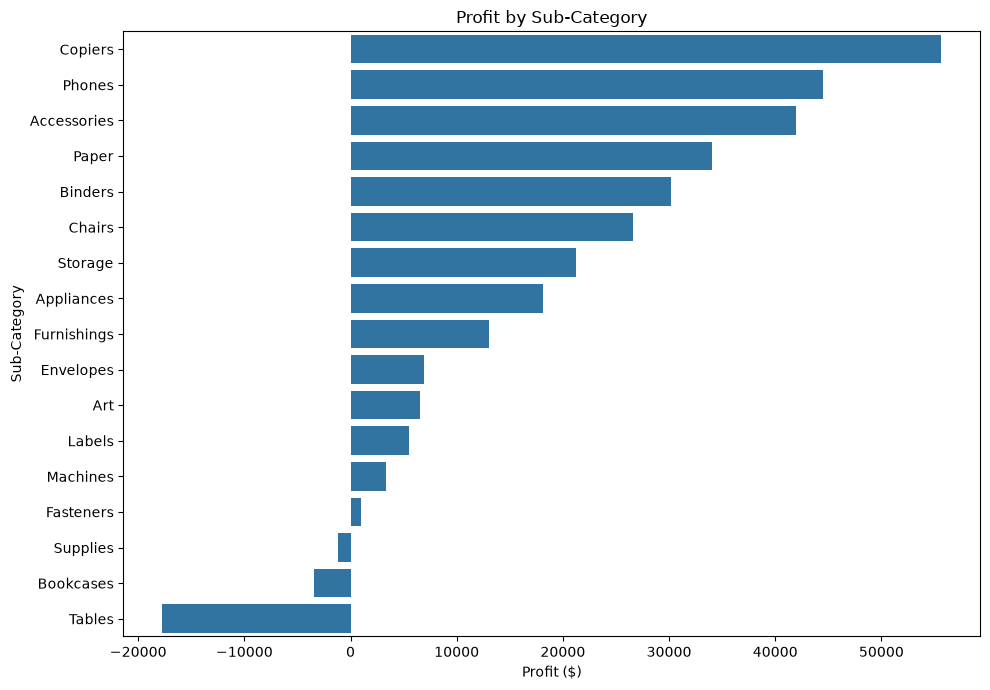

In [17]:
# Profit by Sub-Category

subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=subcategory_profit.values,
    y=subcategory_profit.index
)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

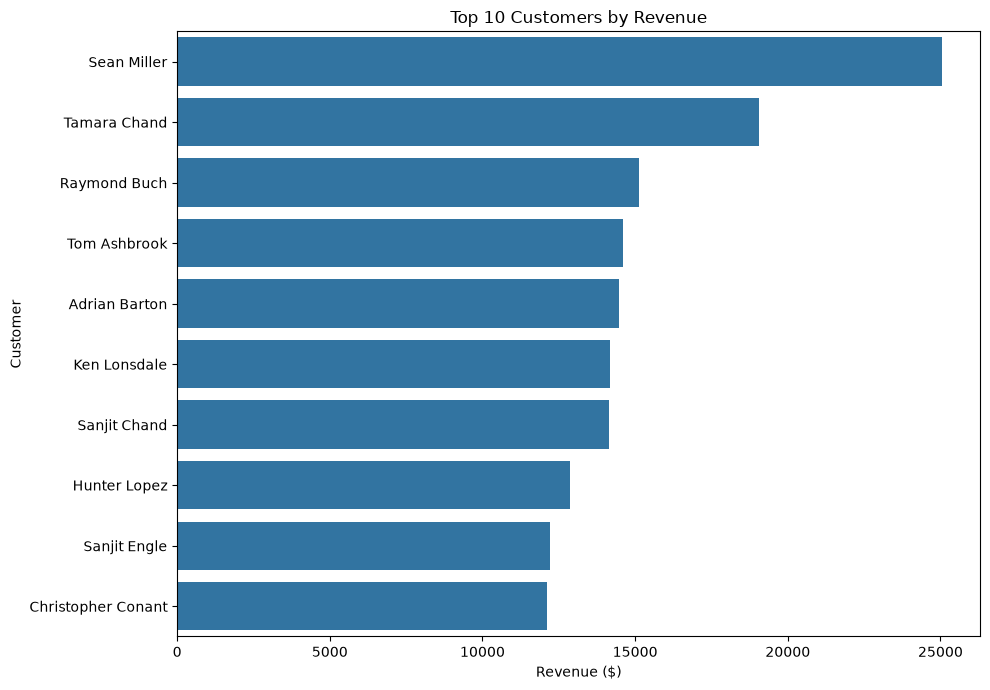

In [18]:
# Top 10 Customers by Revenue

top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

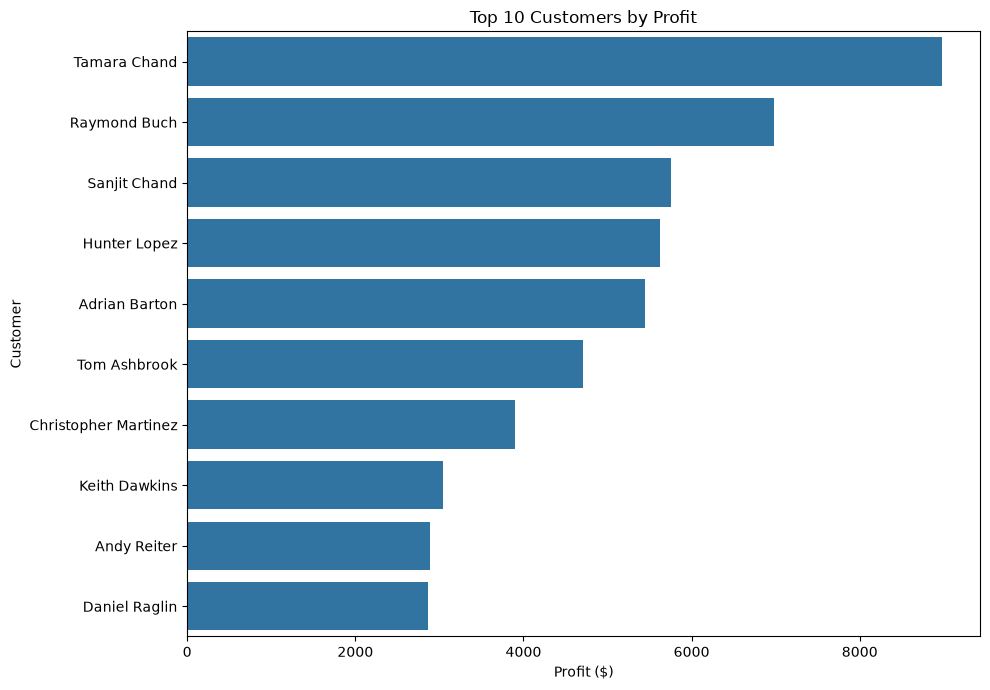

In [19]:
# Top 10 Customers by Profit

top_profit_customers = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_profit_customers.values,
    y=top_profit_customers.index
)

plt.title("Top 10 Customers by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

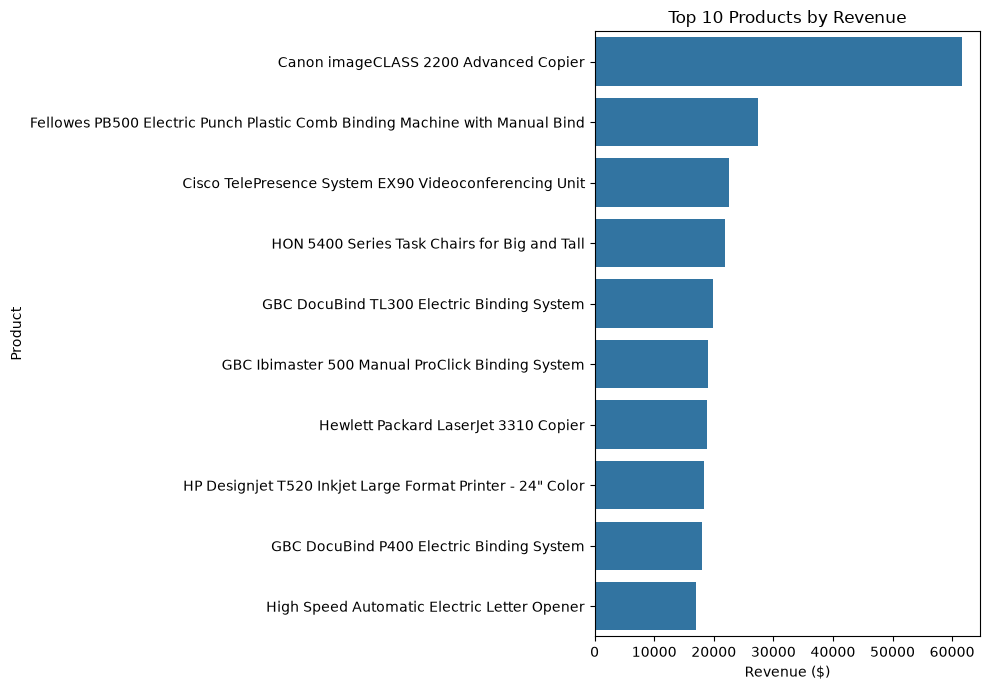

In [20]:
# Top 10 Products by Revenue

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

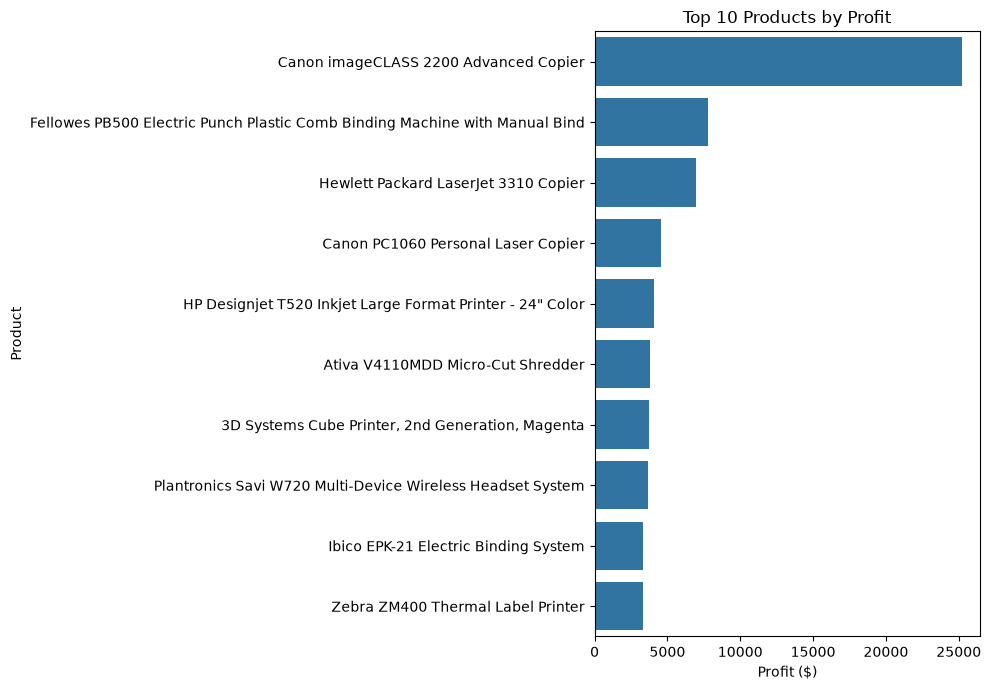

In [21]:
# Top 10 Products by Profit

top_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_profit_products.values,
    y=top_profit_products.index
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

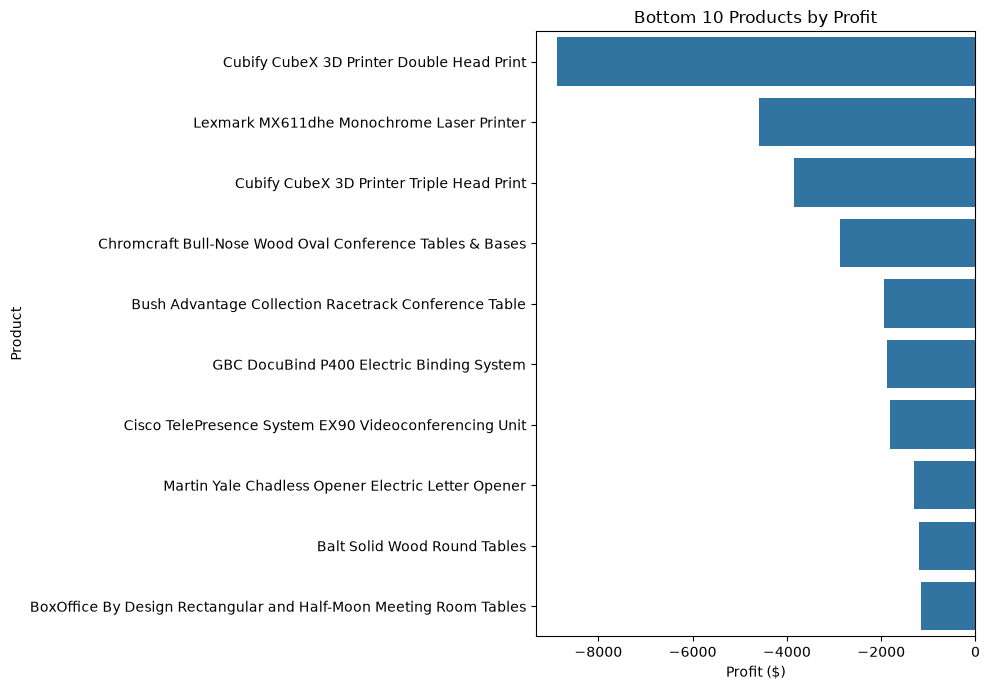

In [22]:
# Bottom 10 Products by Profit

bottom_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=bottom_profit_products.values,
    y=bottom_profit_products.index
)

plt.title("Bottom 10 Products by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

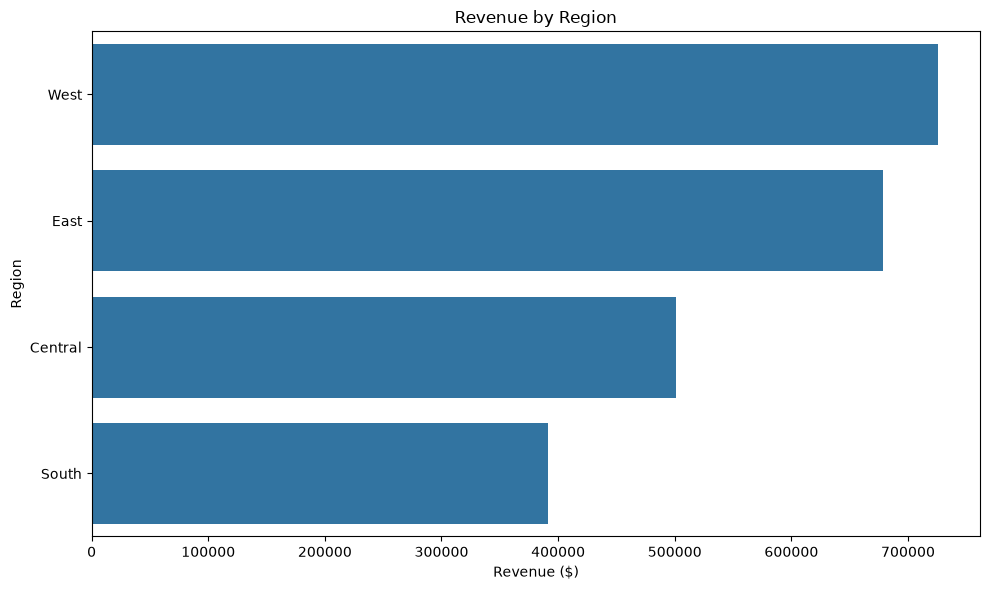

In [23]:
# Revenue by Region

region_revenue = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_revenue.values,
    y=region_revenue.index
)

plt.title("Revenue by Region")
plt.xlabel("Revenue ($)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

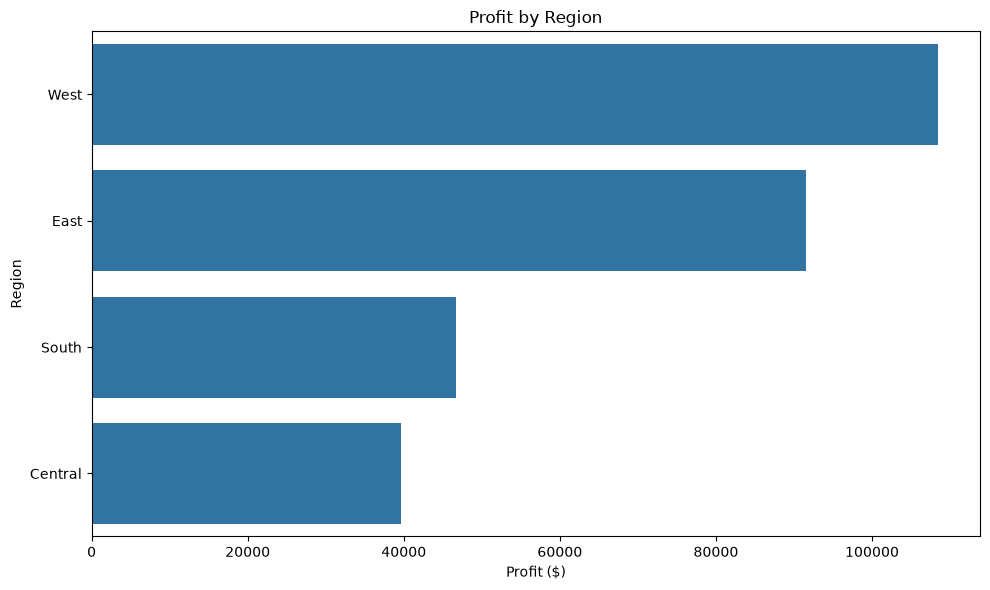

In [24]:
# Profit by Region

region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_profit.values,
    y=region_profit.index
)

plt.title("Profit by Region")
plt.xlabel("Profit ($)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

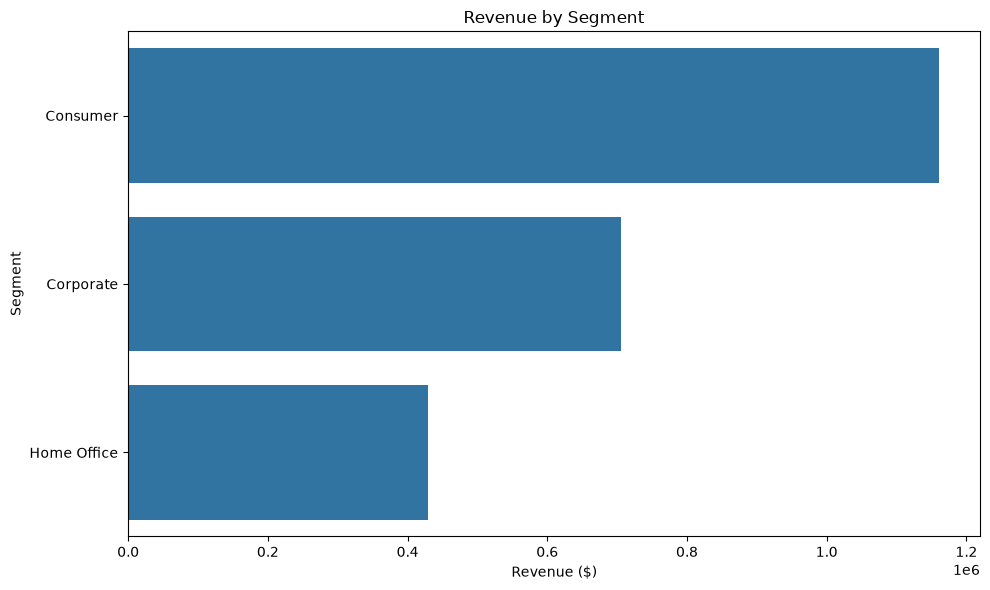

In [25]:
# Revenue by Segment

segment_revenue = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_revenue.values,
    y=segment_revenue.index
)

plt.title("Revenue by Segment")
plt.xlabel("Revenue ($)")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

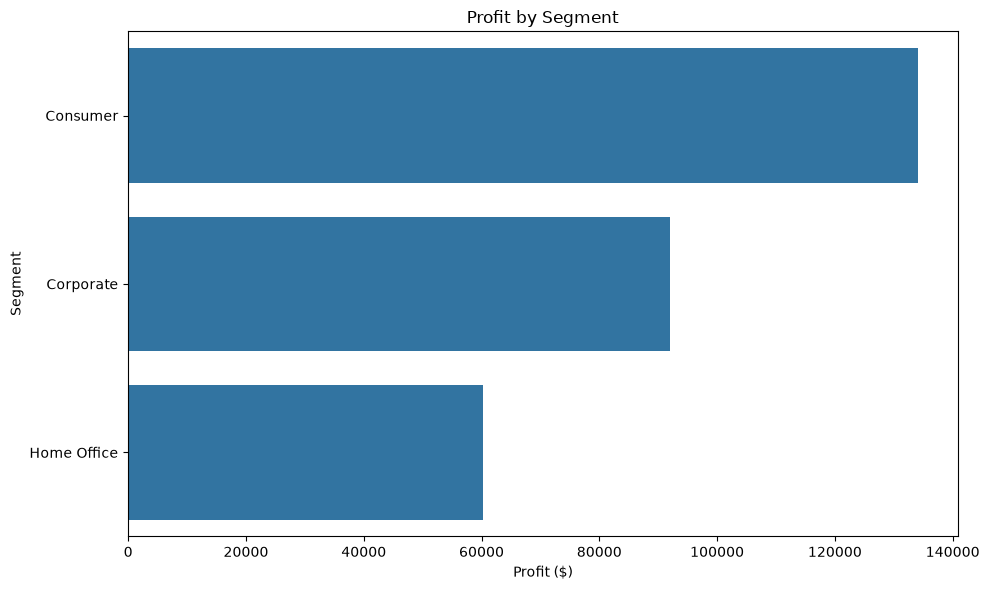

In [26]:
# Profit by Segment

segment_profit = (
    df.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_profit.values,
    y=segment_profit.index
)

plt.title("Profit by Segment")
plt.xlabel("Profit ($)")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

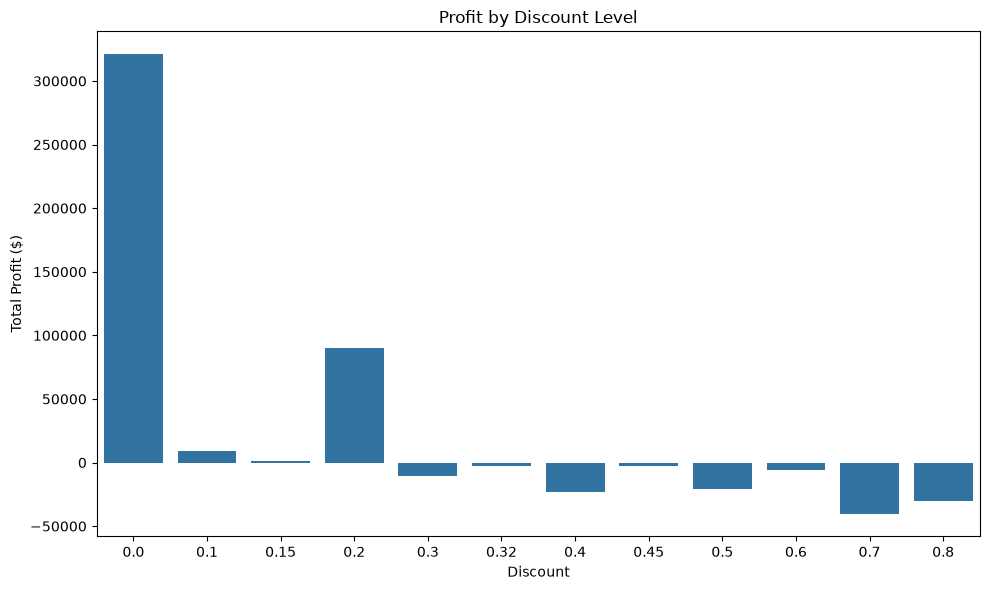

In [27]:
# Profit by Discount Level

discount_profit = (
    df.groupby("Discount")["Profit"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=discount_profit.index,
    y=discount_profit.values
)

plt.title("Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Total Profit ($)")
plt.tight_layout()
plt.show()

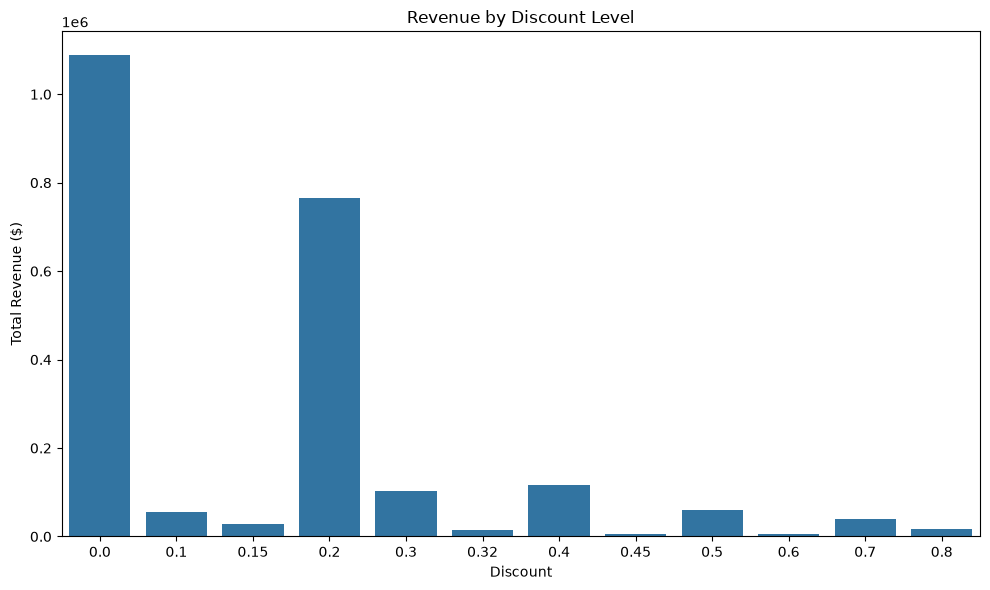

In [28]:
# Revenue by Discount Level

discount_revenue = (
    df.groupby("Discount")["Sales"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=discount_revenue.index,
    y=discount_revenue.values
)

plt.title("Revenue by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.show()